In [1]:

#Assignment No 1

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

In [3]:
# Data Visualization
import matplotlib.pyplot as plt

In [4]:
# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [5]:
# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
# TensorFlow / Keras Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# Step 2 : Load Dataset

# Read the CSV file

df = pd.read_csv("House Price Prediction Dataset.csv")

# Display first five rows

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [8]:
# Step 3 : Dataset Exploration


# Display dataset information

print("Shape of Dataset :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nDataset Information\n")
print(df.info())

print("\nStatistical Summary\n")
print(df.describe())

print("\nMissing Values\n")
print(df.isnull().sum())

Shape of Dataset : (2000, 10)

Column Names

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

Statistical Summary

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.

In [9]:

# Step 4 : Handle Missing Values

# Fill numerical missing values using median

num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values using mode

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning\n")

print(df.isnull().sum())

Missing Values After Cleaning

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_18468\3104745437.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_18468\3104745437.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [10]:

# Step 5 : Encode Categorical Variables
encoder = LabelEncoder()

# Convert text columns into numeric values

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056


In [11]:

# Step 6 : Feature Selection

# Target Column

target = "Price"

# Independent Variables

X = df.drop(target, axis=1)

# Dependent Variable

y = df[target]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (2000, 9)
Target Shape : (2000,)


In [12]:

# Step 7 : Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (1600, 9)
Testing Samples : (400, 9)


In [13]:

# Step 8 : Standardization

# StandardScaler improves ANN performance

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:

# Step 9 : Build Artificial Neural Network

model = Sequential()

# Input Layer + Hidden Layer 1

model.add(Dense(
    units=64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Hidden Layer 2

model.add(Dense(
    units=32,
    activation='relu'
))

# Hidden Layer 3

model.add(Dense(
    units=16,
    activation='relu'
))

# Output Layer

model.add(Dense(
    units=1,
    activation='linear'
))

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:

# Step 10 : Compile Model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display Model Architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:

# Step 11 : Train the ANN

# EarlyStopping prevents overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 367025979392.0000 - mae: 538499.5625 - val_loss: 349356359680.0000 - val_mae: 526881.3750
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 366927347712.0000 - mae: 538407.1250 - val_loss: 349114859520.0000 - val_mae: 526652.1250
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 366282309632.0000 - mae: 537808.4375 - val_loss: 347928068096.0000 - val_mae: 525524.3125
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 363970985984.0000 - mae: 535676.5000 - val_loss: 344400330752.0000 - val_mae: 522157.7500
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 358285901824.0000 - mae: 530314.8750 - val_loss: 336659677184.0000 - val_mae: 514691.0625
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 347060600832.0000 - mae: 519693.0625 - val_loss: 322728689664.0000 - val_mae: 500974.0000
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 328421703680.0000 - mae: 501361.9375 - val_loss

In [17]:
# Step 12 : Evaluate Model

loss, mae = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test MAE :", mae)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 82096668672.0000 - mae: 247680.4375  
Test Loss : 82096668672.0
Test MAE : 247680.4375


In [18]:

# Step 13 : Predict House Prices

y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [19]:

# Step 14 : Performance Evaluation

MAE = mean_absolute_error(y_test, y_pred)

MSE = mean_squared_error(y_test, y_pred)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", MAE)

print("Mean Squared Error :", MSE)

print("Root Mean Squared Error :", RMSE)

print("R² Score :", R2)

Mean Absolute Error : 247680.4375
Mean Squared Error : 82096660480.0
Root Mean Squared Error : 286525.14807604585
R² Score : -0.05524301528930664


In [20]:

# Step 15 : Actual vs Predicted

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.flatten()
})

results.head(20)

,Actual Price,Predicted Price
0,514764,511845.25000
1,694256,526136.25000
2,66375,554608.81250
3,650243,510968.18750
4,223285,521748.68750
5,468127,552497.00000
6,513002,545636.31250
7,911525,488044.96875
8,723265,585079.25000
9,339416,531089.31250


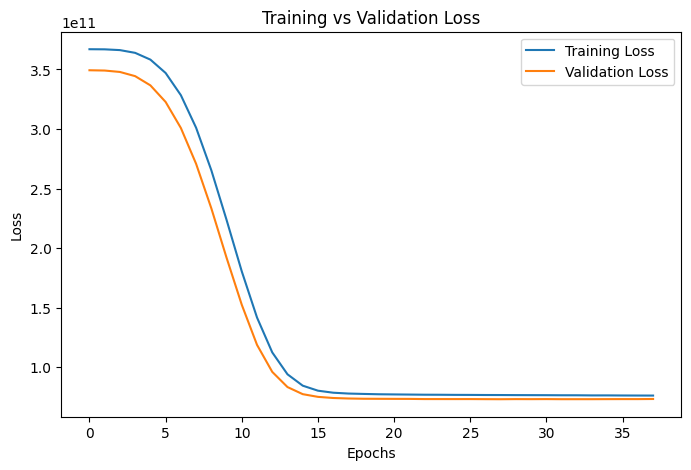

In [21]:

# Step 16 : Training Curve

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

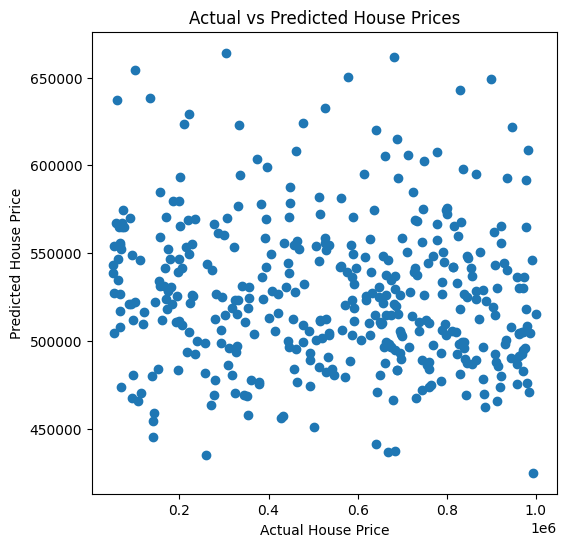

In [22]:

# Step 17 : Scatter Plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()